In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score

X = np.load('../data/features/X_full.npy')
y = np.load('../data/features/y_full.npy')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_train_normal = X_train[y_train == 0]

In [2]:
model = IsolationForest(contamination='auto', random_state=42, n_estimators=200)
model.fit(X_train_normal)

scores = -model.score_samples(X_test)

rows = []
for pct in np.arange(1, 21, 0.5):
    threshold = np.percentile(scores, 100 - pct)
    pred = (scores > threshold).astype(int)
    rows.append({
        'FlaggedPct': pct,
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
    })

sweep = pd.DataFrame(rows)
best = sweep.loc[sweep['F1'].idxmax()]
print("Best threshold:", best.to_dict())

Best threshold: {'FlaggedPct': 4.0, 'Precision': 0.4499126383226558, 'Recall': 0.6117600475153435, 'F1': 0.518499874150516}


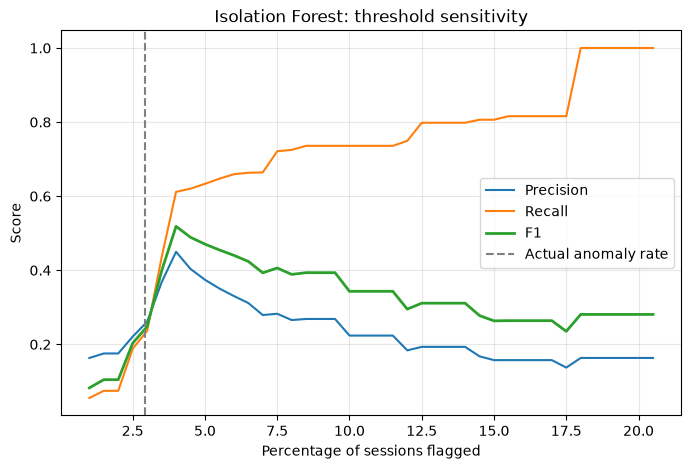

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(sweep['FlaggedPct'], sweep['Precision'], label='Precision')
plt.plot(sweep['FlaggedPct'], sweep['Recall'], label='Recall')
plt.plot(sweep['FlaggedPct'], sweep['F1'], label='F1', linewidth=2)
plt.axvline(2.93, linestyle='--', color='gray', label='Actual anomaly rate')
plt.xlabel('Percentage of sessions flagged')
plt.ylabel('Score')
plt.title('Isolation Forest: threshold sensitivity')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../results/if_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

sweep.to_csv('../results/if_threshold_sweep.csv', index=False)